In [3]:
# ----- 1a -----

import random as rd

randIntegers = []
for i in range(10):
    randInt = rd.randint(50,100)
    randIntegers.append(randInt)

print(randIntegers)

[86, 67, 83, 58, 59, 83, 81, 53, 71, 50]


In [2]:
# ----- 1b -----

randIntegers = []
while len(randIntegers)<10:
    randInt = rd.randint(50,100)
    randIntegers.append(randInt)

print(randIntegers)

[66, 82, 87, 87, 68, 87, 52, 58, 53, 51]


In [3]:
# ----- 1c -----

meanVal = sum(randIntegers)/len(randIntegers)
print(meanVal)

# ----- 1d -----

expectedVal = 0
for i in range(50,101): # note that range does not include the stopping integer!
    expectedVal = expectedVal + i*1/51

print(expectedVal)

69.1
74.99999999999996


In [ ]:
# ----- 1e -----

# a function to compute the mean of a list
# `l` is a list for which we calculate the mean
def mean(l):
    return sum(l) / len(l)

# a function to compute the standard deviation of a list
# `l` is a list for which we calculate the std
def std(l):
    lMean = mean(l)
    standerdDev = mean([(el-mean(l))**2 for el in l])**(0.5)
    return standerdDev

# a function to perform one experiment, where we draw `N` integers and calculate the mean
def meanOfRandInts(n):
    randIntegers = []
    while len(randIntegers)<n:
        randInt = rd.randint(50,100)
        randIntegers.append(randInt)

    return mean(randIntegers)

nExps = 1000 # number of times to perform experiment
nDraws = 10 # number of draws per experiment

# a list with M runs of the experiment where N integers are drawn
meanExperiments = [meanOfRandInts(nDraws) for i in range(nExps)]
print(meanExperiments)
print(std(meanExperiments))


for n in [10,50,100,500]:
    meanExperiments = [meanOfRandInts(n) for i in range(nExps)]
    standardError = std(meanExperiments)
    standardError = std(meanExperiments)
    print("draws: ", n)
    print("standard error: ", standardError)

#the estimate of the true mean gets better (has lower standard deviation) the more draws we take.

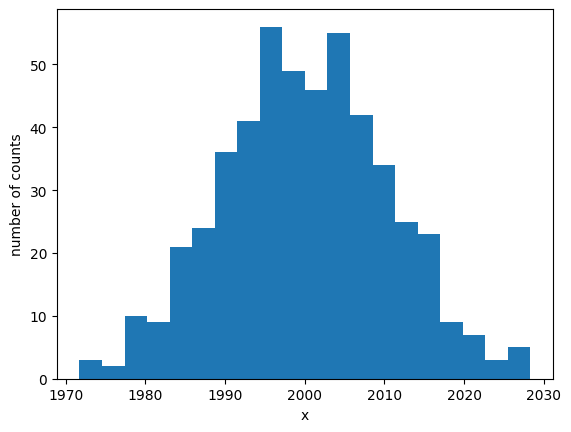

In [4]:
# ----- 2a -----

mean = 2000
var = 103
nVars = 500

randGauss = []
for ie in range(nVars):
    randGauss.append(rd.gauss(2000, var**(1/2)))

# alternative approach: use list comprehension
randGauss = [rd.gauss(2000, var**(1/2)) for x in range(nVars)]

import matplotlib.pyplot as plt

plt.hist(randGauss, 20)
plt.xlabel("x")
plt.ylabel("number of counts")
plt.show()

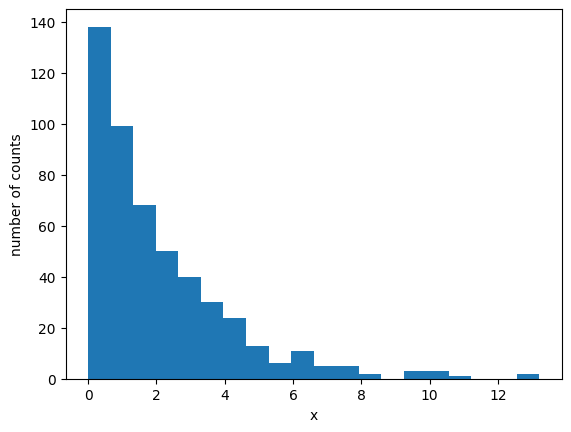

2.091976783747906
2.1022463393622837


In [5]:
# ----- 2b -----

rate = 0.5
# mean = 1/rate
# std = 1/rate
randExp = [rd.expovariate(rate) for i in range(nVars)]

plt.hist(randExp, 20)
plt.xlabel("x")
plt.ylabel("number of counts")
plt.show()

meanObserved = sum(randExp)/len(randExp)
print(meanObserved)
stdObserved = (sum([rv**2 for rv in randExp])/len(randExp) - meanObserved**2)**0.5
print(stdObserved)

In [ ]:
# ---- 3 -----

import numpy as np
rng = np.random.default_rng() # create a random generator

# ---- 3a ----
randArray = rng.random(10)
print(randArray)

# ---- 3b ----
a = 37
b = 643
randArray = a + rng.random(10)*(b-a)
print(randArray)

# ---- 3c ----
randPick = rng.choice(["a","b","c","d"])
print(randPick)


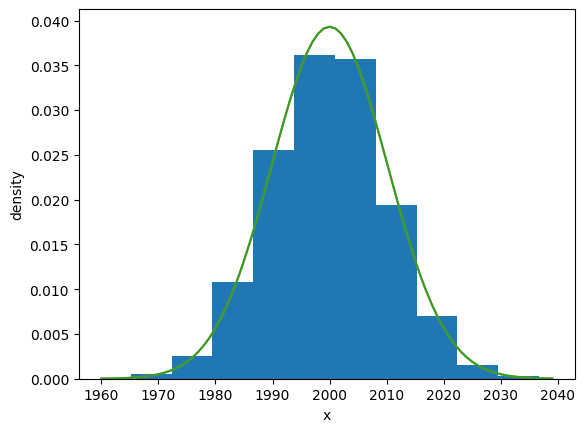

In [75]:
# ----- 4a -----

import scipy.stats
import numpy as np
import numpy.random as rand

mean = 2000
var = 103
std = var**0.5
nVars = 5000

randGaussNumpy = rand.normal(mean, std, nVars)
xVals = range(1960,2040)

def gaussFunc(x):
    return 1/((2*np.pi*var)**0.5) * np.exp( -(x-mean)**2/(2*var) )

# discretize function
norm1Pdf = [gaussFunc(x) for x in xVals]
normDistSciPy = scipy.stats.norm(mean, std)
norm2Pdf = [normDistSciPy.pdf(x) for x in xVals]

plt.hist(randGaussNumpy, density=True)
plt.plot(xVals, norm1Pdf)
plt.plot(xVals, norm2Pdf)
plt.xlabel("x")
plt.ylabel("density")
plt.show()